# Autoencoder on MNIST
This is an autoencoder which uses convolutional layers to try and reproduce MNIST. My idea was to try and reduce the number of latent varaibles to be as small as possible. I found the system doesn't train properly if the number is too few. The fewest I can get so far is 100 (down from the 784 in the data). The images are looking a bit fuzzy though.

In [490]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}\ndevice: {device}")

PyTorch version: 2.7.1
torchvision version: 0.22.1
device: cpu


In [491]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

len(train_data.data), len(test_data.data)

(60000, 10000)

In [ ]:
from torch.utils.data import DataLoader
batch_size = 32

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle = False)

print(f"Train dataloader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Test dataloader: {len(test_dataloader)} batches of size {batch_size}")

Train dataloader: 1875 batches of size 32
Test dataloader: 313 batches of size 32


In [493]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [494]:
class conv_autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=5, stride=3, padding=2),
            nn.ReLU(),
            nn.Conv2d(3, 4, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(3, 1, kernel_size=5, stride=3, padding=2, output_padding=0),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
class dense_autoencoder(nn.Module):
    def __init__(self):
        latent_dim = 20
        super().__init__()

        self.encoder = nn.Linear(28*28, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 28 * 28)#,
            #nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(x.size(0), 28, 28)
        return decoded

In [496]:
ae_model = dense_autoencoder()

In [497]:
optimizer = torch.optim.SGD(params=ae_model.parameters(), lr=0.1)
#optimizer = torch.optim.Adam(params=ae_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
def accuracy_fn(pred, true):
    # can make this later
    pass

In [498]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device: torch.device = device):
    global train_loss
    train_loss = 0
    model.to(device)
    model.train()
    size = len(data_loader)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        X_pred = model(X)
        loss = loss_fn(X, X_pred)
        train_loss += loss/size
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Train loss: {train_loss:.5f}")

In [499]:
train_time_start_on_gpu = timer()
epochs = 20
train_losses = []

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch+1}\n-----------")
    
    train_step(data_loader=train_dataloader, model=ae_model, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)
    train_losses.append(train_loss.item())
train_time_end_on_gpu = timer()
total_train_time = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1
-----------


/Users/charlieardern/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32, 28, 28])) that is different to the input size (torch.Size([32, 1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  5%|▌         | 1/20 [00:05<01:36,  5.09s/it]

Train loss: 0.07532
Epoch: 2
-----------


 10%|█         | 2/20 [00:09<01:22,  4.61s/it]

...

Train loss: 0.06773
Epoch: 19
-----------


 95%|█████████▌| 19/20 [01:26<00:04,  4.68s/it]

Train loss: 0.06769
Epoch: 20
-----------


100%|██████████| 20/20 [01:31<00:00,  4.56s/it]

Train loss: 0.06766
Train time on cpu: 91.263 seconds


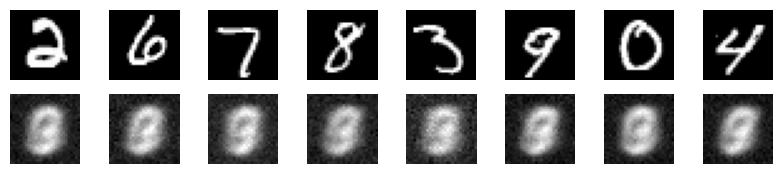

In [500]:
fig, axs = plt.subplots(2, 8, figsize=(10,2))
item_start_index = 82
#fig.axis(False)
#plt.axis(False);
for i in range(8):
    image, label = ae_model(train_data[item_start_index+i][0]).detach(), train_data[item_start_index +i][1]
    axs[1,i].imshow(image.permute(1,2,0), cmap='grey')
    axs[1,i].axis('off')
for i in range(8):
    image, label = train_data[item_start_index+i]
    axs[0,i].imshow(image.permute(1,2,0), cmap='grey')
    axs[0,i].axis('off')

In [501]:
image.shape

torch.Size([1, 28, 28])

In [502]:
x = image
x = x.view(x.size(0), -1)
x = x.view(x.size(0), 28, 28)

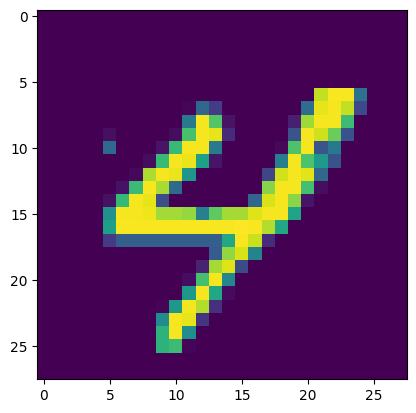

In [503]:
plt.imshow(x.permute(1,2,0))